### QUESTION 1 (G):
#### plot that displays, for each integer value of n from 1 to 100,000, the probability that the jth observation is in the bootstrap sample

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# creating n from 1 to 100,000
n = np.arange(1, 100001)

In [5]:
# P(jth observation is in the bootstrap sample) = 1 - (1 - 1/n)^n
prob = 1 - (1 - 1 / n) ** n

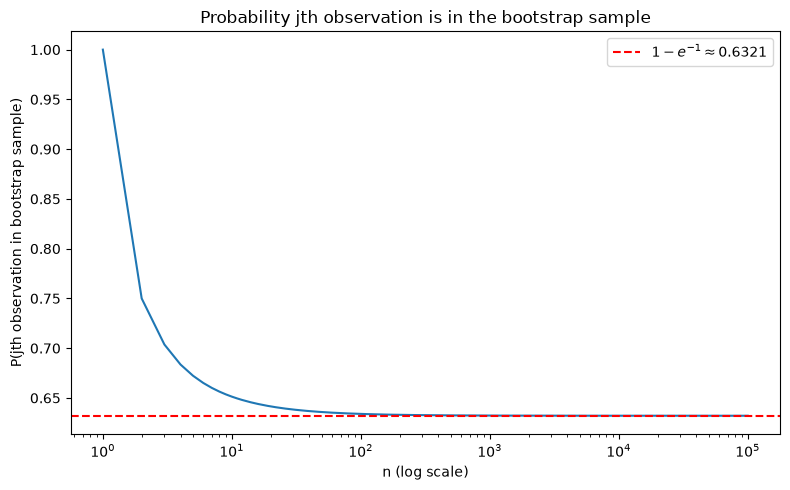

Probability at n = 100,000: 0.6321223982317534


In [7]:
plt.figure(figsize=(8, 5))
plt.plot(n, prob)
plt.xscale('log')
plt.axhline(1 - np.exp(-1), color='red', linestyle='--',
            label=r'$1-e^{-1}\approx 0.6321$')
plt.xlabel('n (log scale)')
plt.ylabel('P(jth observation in bootstrap sample)')
plt.title('Probability jth observation is in the bootstrap sample')
plt.legend()
plt.tight_layout()
plt.show()

print("Probability at n = 100,000:", prob[-1])

### Question 1 (H)
#### Investigating numerically the probability that a bootstrap sample of size n=100 contains the jth observation. where j=4.repeatedly create bootstrap samples, and each time we record whether or not the fifth observation is contained in the bootstrap sample.

In [13]:
rng = np.random.default_rng(10)
store = np.empty(10000)

for i in range(10000):
    store[i] = np.sum(rng.choice(100, size=100, replace=True) == 4) > 0

np.mean(store)

np.float64(0.6362)

### Question 2 

In [16]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from ISLP import load_data

In [18]:
# Loading data
Weekly = load_data('Weekly')
n = len(Weekly)

y = (Weekly['Direction'] == 'Up').astype(int)
X = sm.add_constant(Weekly[['Lag1', 'Lag2']])

In [20]:
# (a) Fitting logistic regression on the full data set
model_full = sm.GLM(y, X, family=sm.families.Binomial()).fit()
print("(a) Full-data model coefficients:")
print(model_full.params)
print()

(a) Full-data model coefficients:
const    0.221224
Lag1    -0.038722
Lag2     0.060248
dtype: float64



In [22]:
# (b) Fitting logistic regression using all but the first observation
X_b = X.drop(0)
y_b = y.drop(0)
model_b = sm.GLM(y_b, X_b, family=sm.families.Binomial()).fit()
print("(b) Model coefficients (excluding observation 1):")
print(model_b.params)
print()

(b) Model coefficients (excluding observation 1):
const    0.223243
Lag1    -0.038433
Lag2     0.060848
dtype: float64



In [24]:
# (c) Predicting the direction of the first observation using model (b)
pred_prob_1 = model_b.predict(X.iloc[[0]])
pred_class_1 = "Up" if pred_prob_1.values[0] > 0.5 else "Down"
actual_1 = Weekly['Direction'].iloc[0]

print("(c) Prediction for observation 1:")
print("Predicted probability of Up:", pred_prob_1.values[0])
print("Predicted class:", pred_class_1)
print("Actual class:", actual_1)
print("Correctly classified?", pred_class_1 == actual_1)
print()


(c) Prediction for observation 1:
Predicted probability of Up: 0.5713923205204429
Predicted class: Up
Actual class: Down
Correctly classified? False



In [26]:
# (d) LOOCV loop over all n observations
errors = np.zeros(n)

for i in range(n):
    X_train = X.drop(i)
    y_train = y.drop(i)

    # i. fit on all but the ith observation
    m = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit()

    # ii. posterior probability for the ith observation
    prob_i = m.predict(X.iloc[[i]]).values[0]

    # iii. classify using 0.5 threshold
    pred_i = 1 if prob_i > 0.5 else 0

    # iv. record error indicator (1 = error, 0 = correct)
    errors[i] = int(pred_i != y.iloc[i])

In [30]:
# (e) LOOCV test error estimate
loocv_error = np.mean(errors)
print("(e) LOOCV test error estimate:", loocv_error)

(e) LOOCV test error estimate: 0.44995408631772266
